# Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal
import matplotlib.pyplot as plt

# Preparing shape features

In [2]:
# 1. Configuration and path definition
MAIN_FOLDER_PATH = Path(r"E:\DATA_Myelomy")

all_patients_stats = []

# ==================================================================
# FEATURE EXTRACTION: Aggregating Shape Statistics Across Patients
# ==================================================================

if MAIN_FOLDER_PATH.exists():
    for patient_folder in MAIN_FOLDER_PATH.iterdir():
        # Process only actual directories (patient folders)
        if not patient_folder.is_dir():
            continue

        # Find all files matching the target pattern within the patient's directory
        # Using glob on Path objects for cleaner pattern matching
        csv_files = list(patient_folder.glob("*individual_lesion_features*.csv"))

        # Safety Check 1: If no matching CSV file is found, skip this patient
        if not csv_files:
            print(f"Warning: No matching CSV found in {patient_folder.name}. Skipping.")
            continue

        # Choose the first file (as shape features remain identical across image types)
        target_csv_path = csv_files[0]

        # Load the CSV and filter only columns that contain "shape" in their name
        df_shape = pd.read_csv(target_csv_path).filter(like="shape")

        # Safety Check 2: If the CSV contains no shape features, skip processing
        if df_shape.empty:
            continue

        # Initialize the statistics dictionary for the current patient
        patient_metrics = {"patient_id": patient_folder.name}

        # Compute descriptive statistics for each shape feature column
        for column_name in df_shape.columns:
            series = df_shape[column_name].dropna()

            # Skip if there are no values left after dropping NaNs
            if series.empty:
                continue

            mean_val = series.mean()
            std_val = series.std()

            patient_metrics[f"{column_name}_mean"] = mean_val
            patient_metrics[f"{column_name}_median"] = series.median()
            patient_metrics[f"{column_name}_std"] = std_val
            patient_metrics[f"{column_name}_var"] = series.var()

            # Coefficient of Variation (CV) protection: prevent DivisionByZero if mean is 0
            patient_metrics[f"{column_name}_cv"] = (std_val / mean_val) if mean_val != 0 else np.nan

            patient_metrics[f"{column_name}_range"] = series.max() - series.min()
            patient_metrics[f"{column_name}_min"] = series.min()
            patient_metrics[f"{column_name}_max"] = series.max()

        # Append the patient's calculated metrics to the master collection
        all_patients_stats.append(patient_metrics)

# 2. Finalize into a single master summary DataFrame
df_final = pd.DataFrame(all_patients_stats)

# Boxplot visualization

--- Kruskal-Wallis Test Top Results ---
                            Feature      H_all   p_value
0      original_shape_Flatness_mean  14.265137  0.000799
1    original_shape_Flatness_median  13.100096  0.001430
2  original_shape_Elongation_median  11.588060  0.003046
3    original_shape_Elongation_mean  11.188244  0.003720
4      original_shape_Elongation_cv   6.592925  0.037014
--------------------------------------------------


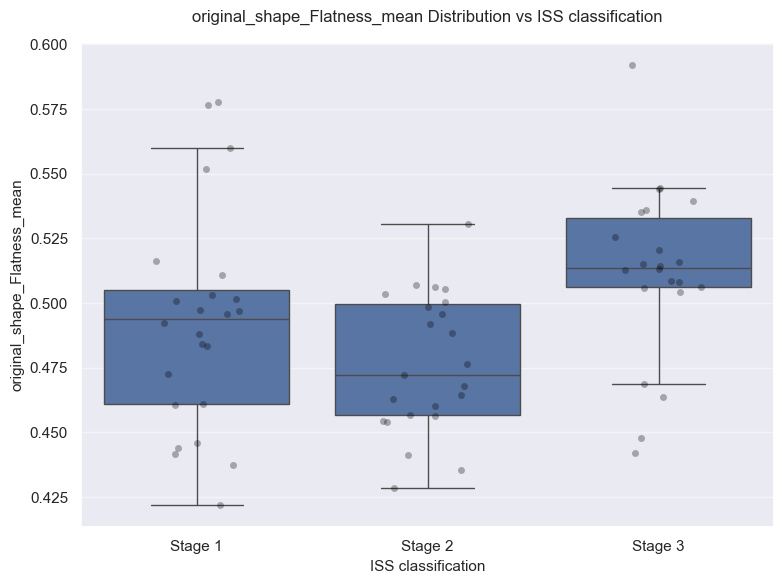

In [4]:
# 1. Global Pandas configuration to handle future deprecations cleanly
pd.set_option('future.no_silent_downcasting', True)

# 2. Load the clinical dataset
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# 3. Merge shape statistics with the clinical staging data
data = pd.merge(
    df_final,
    clinical_df[['Patient ID', 'ISS classification']],
    left_on='patient_id',
    right_on='Patient ID'
)

# Identify numerical features to test
numeric_features = df_final.select_dtypes(include=['number']).columns

# ==================================================================
# STATISTICAL ANALYSIS: Kruskal-Wallis Test across Staging Groups
# ==================================================================
results = []

for feature in numeric_features:
    # Dynamically group the radiomic feature values by the categorical Stage text
    groups = [
        group_data[feature].dropna().values
        for stage_name, group_data in data.groupby('ISS classification')
    ]

    # The test requires at least 2 unique groups containing data
    if len(groups) > 1 and all(len(g) > 0 for g in groups):
        stat, p_value = kruskal(*groups)

        results.append({
            "Feature": feature,
            "H_all": stat,
            "p_value": p_value,
        })

# Store and sort results by significance (lowest p-value)
results_df = pd.DataFrame(results).sort_values(by='p_value').reset_index(drop=True)

print("--- Kruskal-Wallis Test Top Results ---")
print(results_df.head())
print("-" * 50)


# ==================================================================
# VISUALIZATION: Specific Target Feature Distribution Plot
# ==================================================================
img_feature = "original_shape_Flatness_mean"

# Setup clean visualization styles
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))

# Sort the categorical stages alphabetically so 'Stage 1' appears first on the X-axis
stage_order = sorted(data['ISS classification'].dropna().unique())

# Generate the boxplot using the categorical text labels
sns.boxplot(
    data=data,
    x='ISS classification',
    y=img_feature,
    order=stage_order,
    showfliers=False
)

# Overlay individual data points to visualize patient density per group
sns.stripplot(
    data=data,
    x='ISS classification',
    y=img_feature,
    order=stage_order,
    color="black",
    alpha=0.3,
    jitter=0.2
)

# Format titles and labels fully in English
plt.xlabel('ISS classification', fontsize=11)
plt.ylabel(img_feature, fontsize=11)
plt.title(f'{img_feature} Distribution vs ISS classification', fontsize=12, pad=15)

plt.tight_layout()
plt.show()